# PPO-Lagrangian: constrained RL in a simple environment

`PPOLagrangian` (in `safe_rl_baselines`) is a PyTorch safe-RL baseline. In addition to
maximising reward it keeps a **cumulative cost** below a limit:

$$\max_\pi\; \mathbb{E}\!\left[\textstyle\sum_t \gamma^t r_t\right]\quad\text{s.t.}\quad
\mathbb{E}\!\left[\textstyle\sum_t \gamma_c^t c_t\right] \le \text{cost\_limit}.$$

It uses a **cost critic** and a **Lagrange multiplier** $\lambda$: the actor maximises the
combined advantage $(A_r - \lambda A_c)/(1+\lambda)$, and after each rollout $\lambda$ is nudged
up when the average episode cost exceeds the limit and down when it is below — enforcing the
constraint softly via the dual variable.

**Demo:** `CartPole-v1` where pushing **left** (`action == 0`) costs 1 per step. Balancing the
pole normally uses both actions about equally (so the unconstrained cost is high), and a tight
cost budget forces a reward/safety trade-off that the Lagrangian mechanism manages.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from safe_rl_baselines import PPOLagrangian

# Per-step cost: 1 whenever the agent takes the "costly" action (push left).
def left_is_costly(obs, action, reward, next_obs, terminated, truncated, info):
    return 1.0 if int(action) == 0 else 0.0

COST_LIMIT = 5.0    # allow only a small (discounted) amount of the costly action per episode

def make_model(cost_limit):
    return PPOLagrangian(
        gym.make("CartPole-v1"),
        cost_fn=left_is_costly,
        cost_limit=cost_limit,
        n_steps=2048, batch_size=128, n_epochs=10,
        lambda_lr=0.05, seed=0, device="cpu", net_arch=(64, 64),
    )

## Train the constrained agent

We train in chunks to watch the Lagrange multiplier $\lambda$ and the average episode cost
evolve. As the agent learns to balance (which would naturally use the costly action a lot),
$\lambda$ rises and pushes the episode cost down toward `cost_limit`.

In [2]:
model = make_model(COST_LIMIT)

chunk, n_chunks = 2048, 10
steps_hist, lambda_hist, cost_hist = [], [], []
for k in range(1, n_chunks + 1):
    model.learn(total_timesteps=k * chunk)
    steps_hist.append(model.num_timesteps)
    lambda_hist.append(model.lagrangian_multiplier)
    cost_hist.append(model.last_stats.get("mean_episode_cost", float("nan")))
    print(f"steps={model.num_timesteps:6d}  lambda={model.lagrangian_multiplier:6.3f}  "
          f"mean_episode_cost={cost_hist[-1]:7.2f}")

steps=  2048  lambda= 0.355  mean_episode_cost=  12.10


steps=  4096  lambda= 0.619  mean_episode_cost=  10.27


steps=  6144  lambda= 0.677  mean_episode_cost=   6.17


steps=  8192  lambda= 0.580  mean_episode_cost=   3.06


steps= 10240  lambda= 0.445  mean_episode_cost=   2.29


steps= 12288  lambda= 0.442  mean_episode_cost=   4.95


steps= 14336  lambda= 0.291  mean_episode_cost=   1.98


steps= 16384  lambda= 0.331  mean_episode_cost=   5.80


steps= 18432  lambda= 0.272  mean_episode_cost=   3.81


steps= 20480  lambda= 0.413  mean_episode_cost=   7.82


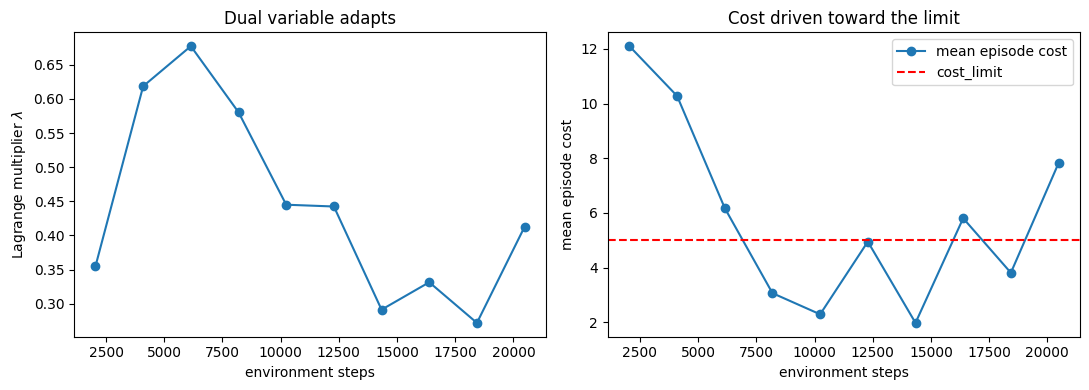

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(steps_hist, lambda_hist, marker="o")
ax1.set_xlabel("environment steps"); ax1.set_ylabel("Lagrange multiplier $\\lambda$")
ax1.set_title("Dual variable adapts")

ax2.plot(steps_hist, cost_hist, marker="o", label="mean episode cost")
ax2.axhline(COST_LIMIT, color="red", ls="--", label="cost_limit")
ax2.set_xlabel("environment steps"); ax2.set_ylabel("mean episode cost")
ax2.set_title("Cost driven toward the limit"); ax2.legend()
plt.tight_layout(); plt.show()

## Compare with an unconstrained agent

With an effectively infinite cost limit the multiplier stays at 0 (plain PPO), so the agent
balances the pole using the costly action freely. We compare the average episode cost and how
often each deterministic policy takes the costly "left" action.

In [4]:
def evaluate(model, episodes=20):
    env = gym.make("CartPole-v1")
    left = total = ep_cost = 0
    for ep in range(episodes):
        obs, _ = env.reset(seed=1000 + ep)
        done = False
        while not done:
            action = int(np.asarray(model.predict(obs, deterministic=True)[0]))
            left += int(action == 0); total += 1; ep_cost += int(action == 0)
            obs, _, term, trunc, _ = env.step(action)
            done = term or trunc
    return left / total, ep_cost / episodes

unconstrained = make_model(cost_limit=1e9)
unconstrained.learn(total_timesteps=n_chunks * chunk)

c_freq, c_cost = evaluate(model)
u_freq, u_cost = evaluate(unconstrained)
print(f"constrained  (limit={COST_LIMIT}): lambda={model.lagrangian_multiplier:.2f}  "
      f"costly-action freq={c_freq:.2f}  mean episode cost={c_cost:.1f}")
print(f"unconstrained             : lambda={unconstrained.lagrangian_multiplier:.2f}  "
      f"costly-action freq={u_freq:.2f}  mean episode cost={u_cost:.1f}")

constrained  (limit=5.0): lambda=0.41  costly-action freq=0.00  mean episode cost=0.0
unconstrained             : lambda=0.00  costly-action freq=0.50  mean episode cost=249.5


## Using the trained policy

`predict` returns the action for an observation (`deterministic=True` for the greedy action);
`model.lagrangian_multiplier` and `model.last_stats` expose the constraint diagnostics.

In [5]:
obs, _ = gym.make("CartPole-v1").reset(seed=0)
action, _ = model.predict(obs, deterministic=True)
print("observation:", np.round(obs, 3), "-> action:", int(np.asarray(action)))
print("final lambda:", round(model.lagrangian_multiplier, 3))
print("last stats:", {k: round(v, 3) for k, v in model.last_stats.items()})

observation: [ 0.014 -0.023 -0.046 -0.048] -> action: 1
final lambda: 0.413
last stats: {'policy_loss': -0.006, 'value_loss': 25.446, 'lagrangian_multiplier': 0.413, 'mean_cost_advantage': 1.131, 'mean_cost_return': 3.699, 'mean_episode_cost': 7.817}
